# Telco Customer Churn — Model Training

This notebook focuses on training machine learning models to predict customer churn using the cleaned Telco Customer Churn dataset.

The objective is to build reproducible training pipelines and compare different classification algorithms.

## Modeling Goals

The model training stage focuses on:

- Preparing features for machine learning models
- Building preprocessing pipelines
- Preventing data leakage
- Performing cross-validation
- Exploring hyperparameter tuning
- Comparing multiple classification models
- Creating reproducible training workflows

## Models Used

The following machine learning models are explored:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- XGBoost Classifier

## Import Section

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from joblib import Memory, dump
from scipy.stats import loguniform, randint, uniform
from sklearn.compose import (
	ColumnTransformer,
	make_column_selector,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
	ConfusionMatrixDisplay,
	RocCurveDisplay,
	accuracy_score,
	classification_report,
	confusion_matrix,
	f1_score,
	precision_score,
	recall_score,
	roc_auc_score,
)
from sklearn.model_selection import (
	RandomizedSearchCV,
	RepeatedStratifiedKFold,
	train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

/workspace/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Processed Dataset

The dataset used in this notebook was previously cleaned and standardized during the data preparation stage.

In [2]:
telco_churn = pd.read_parquet('../data/processed/telco_churn_clean.parquet')

In [3]:
telco_churn.sample(5)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
2798,Male,0,No,No,10,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.900002,Yes
2381,Male,0,No,No,11,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.500000,No
1615,Female,0,Yes,No,49,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Bank transfer (automatic),20.049999,No
2407,Female,0,Yes,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.699997,Yes
5041,Male,0,Yes,No,20,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.650000,No


## Reproducibility Configuration

A fixed random state is defined to ensure reproducible experiments across all training procedures.

In [4]:
RANDOM_STATE = 42

## Feature and Target Definition

The dataset is separated into:

- Features (X)
- Target variable (y)

Customer churn is used as the prediction target.

In [5]:
X = telco_churn.drop('Churn', axis=1)
y = telco_churn['Churn']

In [6]:
X.shape, y.shape

((7043, 18), (7043,))

## Train-Test Split

The dataset is divided into training and testing subsets.

Stratification is applied to preserve the original churn distribution.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

In [8]:
X_train.shape, y_train.shape

((5634, 18), (5634,))

In [9]:
X_train.dtypes

Gender              category
SeniorCitizen          int64
Partner             category
Dependents          category
Tenure                 int16
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float32
dtype: object

In [10]:
y_train.dtypes

CategoricalDtype(categories=['No', 'Yes'], ordered=False, categories_dtype=str)

In [11]:
X_test.shape, y_test.shape

((1409, 18), (1409,))

## Feature Preprocessing

Different preprocessing strategies are applied depending on feature type:

- Numerical features are standardized using scaling transformations
- Categorical features are encoded using one-hot encoding

Separate preprocessing pipelines are combined using a ColumnTransformer to centralize transformations and ensure reproducible workflows.

In [12]:
num_pipe = Pipeline(
	steps=[
		('scl', StandardScaler()),
	]
)

In [13]:
display(num_pipe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scl', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [14]:
cat_pipe = Pipeline(
	steps=[
		('enc', OneHotEncoder(handle_unknown='ignore')),
	]
)

In [15]:
display(cat_pipe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('enc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies 

In [16]:
num_cols = make_column_selector(dtype_include=np.number)
cat_cols = make_column_selector(dtype_include='category')

In [17]:
preprocessor = ColumnTransformer(
	transformers=[
		('num', num_pipe, num_cols),
		('cat', cat_pipe, cat_cols),
	],
)

In [18]:
display(preprocessor)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Cross-Validation Strategy

Repeated Stratified K-Fold cross-validation is used to preserve class proportions across validation folds while improving robustness through multiple repetitions.

This strategy reduces variance in performance estimation and provides more stable evaluation results for imbalanced classification tasks.

In [19]:
RSKF_N_SPLITS = 5
RSKF_N_REPEATS = 10

In [20]:
rskf = RepeatedStratifiedKFold(
	n_splits=RSKF_N_SPLITS, n_repeats=RSKF_N_REPEATS, random_state=RANDOM_STATE
)

# Logistic Regression

## Pipeline Definition

A machine learning pipeline is created to combine:

- Feature preprocessing
- Logistic Regression training

This structure prevents leakage and guarantees reproducible workflows.

In [21]:
# Logistic Regression is configured with balanced class weights
# to compensate for the moderate imbalance between churned and
# retained customers.
logreg_clf = LogisticRegression(
	class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000
)

In [22]:
memory = Memory(location='../cache', verbose=0)

In [23]:
logreg_pipe = Pipeline(
	steps=[
		('prep', preprocessor),
		('clf', logreg_clf),
	],
	memory=memory,
)

In [24]:
display(logreg_pipe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati.../cache/joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

## Hyperparameter Search Space

A randomized hyperparameter search is configured to explore different Logistic Regression configurations.

In [25]:
logreg_param_dist = [
	{
		'clf__solver': ['lbfgs', 'newton-cholesky'],
		'clf__l1_ratio': [0.0],
		'clf__C': loguniform(1e-6, 1e6),
	},
	{
		'clf__solver': ['saga'],
		'clf__l1_ratio': uniform(0, 1),
		'clf__C': loguniform(1e-6, 1e6),
	},
]

## Randomized Search Configuration

RandomizedSearchCV is used to:

- Train multiple parameter combinations
- Perform cross-validation
- Compare model configurations
- Select the best-performing estimator

In [26]:
logreg_search = RandomizedSearchCV(
	estimator=logreg_pipe,
	param_distributions=logreg_param_dist,
	n_iter=50,
	scoring='roc_auc',
	n_jobs=-1,
	cv=rskf,
	random_state=RANDOM_STATE,
)

In [27]:
logreg_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(memo...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'clf__C': <scipy.stats....x7f1c86029940>, 'clf__l1_ratio': [0.0], 'clf__solver': ['lbfgs', 'newton-cholesky']}, {'clf__C': <scipy.stats....x7f1c8601d810>, 'clf__l1_ratio': <scipy.stats....x7f1c8601d590>, 'clf__solver': ['saga']}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same acr

## Best Hyperparameters

The randomized search identified the best Logistic Regression configuration based on ROC-AUC performance during cross-validation.

The selected parameters represent the configuration that achieved the best balance between model generalization and predictive performance.

In [28]:
display(logreg_search.best_params_)

{'clf__C': np.float64(6.492380039151365),
 'clf__l1_ratio': np.float64(0.03131329245555858),
 'clf__solver': 'saga'}

## Cross-Validation Performance

The best cross-validation ROC-AUC score obtained during hyperparameter search is analyzed below.

ROC-AUC is particularly useful for churn prediction because it evaluates the model's ability to distinguish churned customers from retained customers across different classification thresholds.

In [29]:
display(logreg_search.best_score_)

np.float64(0.8444826872491319)

## Best Estimator

In [30]:
best_logreg_clf = logreg_search.best_estimator_

In [31]:
display(best_logreg_clf)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati.../cache/joblib)
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

## Test Set Inference

After selecting the best estimator through cross-validation, the optimized pipeline is applied to the unseen test set.

This step simulates real-world inference by evaluating the model on data that was not used during training or hyperparameter optimization.

Both class predictions and predicted probabilities are generated for downstream performance evaluation.

In [32]:
y_pred_logreg = best_logreg_clf.predict(X_test)

y_proba_logreg = best_logreg_clf.predict_proba(X_test)[:, 1]

## Model Evaluation Metrics

The trained Logistic Regression model is evaluated using multiple classification metrics on the test set.

Since customer churn prediction is a moderately imbalanced classification task, multiple evaluation metrics are analyzed to provide a more complete assessment of model performance.

The evaluation includes:

- ROC-AUC Score
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

These metrics help assess the model's ability to correctly identify churned customers while balancing false positives and false negatives.

In [33]:
logreg_roc_auc = roc_auc_score(y_test, y_proba_logreg)

In [34]:
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)

In [35]:
logreg_precision = precision_score(y_test, y_pred_logreg, pos_label='Yes')

In [36]:
logreg_recall = recall_score(y_test, y_pred_logreg, pos_label='Yes')

In [37]:
logreg_f1 = f1_score(y_test, y_pred_logreg, pos_label='Yes')

In [38]:
print(f'ROC-AUC  : {logreg_roc_auc:.4f}')
print(f'Accuracy : {logreg_accuracy:.4f}')
print(f'Precision: {logreg_precision:.4f}')
print(f'Recall   : {logreg_recall:.4f}')
print(f'F1-Score : {logreg_f1:.4f}')

ROC-AUC  : 0.8376
Accuracy : 0.7402
Precision: 0.5070
Recall   : 0.7754
F1-Score : 0.6131


### Classification Report

A detailed classification report is generated to summarize model performance across both churn classes.

In [39]:
logreg_report = classification_report(
    y_test,
    y_pred_logreg,
    output_dict=True
)

In [40]:
df_logreg_report = pd.DataFrame(logreg_report).transpose()

df_logreg_report = df_logreg_report.iloc[:-1, :]

In [41]:
display(df_logreg_report)

,precision,recall,f1-score,support
No,0.899642,0.727536,0.804487,1035.000000
Yes,0.506993,0.775401,0.613108,374.000000
accuracy,0.740241,0.740241,0.740241,0.740241
macro avg,0.703317,0.751469,0.708798,1409.000000


### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of prediction outcomes, including correctly and incorrectly classified samples.

This visualization helps analyze the trade-off between false positives and false negatives, which is particularly important in churn prediction tasks.

In [42]:
logreg_labels_cm = best_logreg_clf.classes_

logreg_cm = confusion_matrix(y_test, y_pred_logreg, labels=logreg_labels_cm)

disp_cm = ConfusionMatrixDisplay(
	confusion_matrix=logreg_cm, display_labels=logreg_labels_cm
)

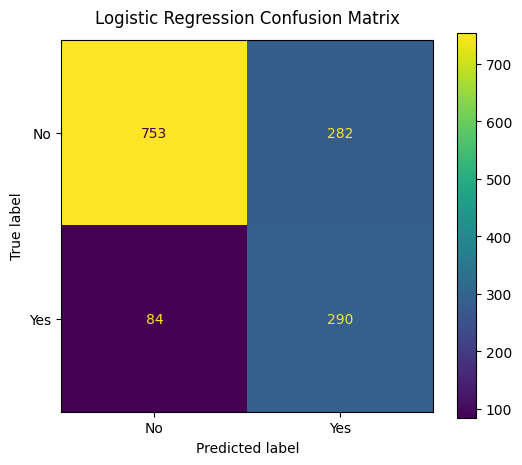

In [43]:
fig, ax = plt.subplots(figsize=(6, 5))

disp_cm.plot(cmap='viridis', ax=ax)

ax.set_title('Logistic Regression Confusion Matrix', pad=12)

plt.show()

### ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve illustrates the model's ability to separate churned and retained customers across multiple classification thresholds.

The closer the curve approaches the top-left corner, the better the model's discriminative performance.

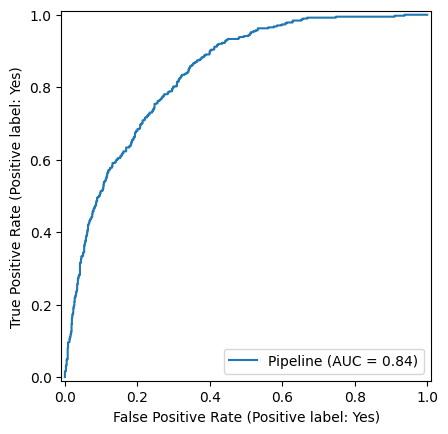

In [44]:
RocCurveDisplay.from_estimator(best_logreg_clf, X_test, y_test)

## Model Export and Saved Artifacts

The best trained pipeline and training metadata are exported
for downstream evaluation and deployment workflows.

The following artifacts are persisted:

- Best trained Logistic Regression pipeline
- Best hyperparameter configuration
- Best cross-validation ROC-AUC score

The exported pipeline includes both preprocessing and model training steps,
ensuring reproducible transformations during future inference tasks.

In [45]:
base_logreg_path = '../models/logistic_regression'

os.makedirs(base_logreg_path, exist_ok=True)

In [46]:
logreg_artifacts = {
	'model_name': 'logistic_regression',
	'best_params': logreg_search.best_params_,
	'best_cv_score': logreg_search.best_score_,
	'best_index': logreg_search.best_index_,
	'test_metrics': {
		'test_roc_auc': logreg_roc_auc,
		'test_accuracy': logreg_accuracy,
		'test_precision': logreg_precision,
		'test_recall': logreg_recall,
		'test_f1': logreg_f1,
	},
	'cv_strategy': {
		'type': 'RepeatedStratifiedKFold',
		'n_splits': RSKF_N_SPLITS,
		'n_repeats': RSKF_N_REPEATS,
	},
	'random_state': RANDOM_STATE,
}

dump(
	logreg_artifacts,
	filename=f'{base_logreg_path}/logreg_artifacts.joblib',
)

['../models/logistic_regression/logreg_artifacts.joblib']

In [47]:
dump(
	best_logreg_clf,
	filename=f'{base_logreg_path}/logreg_best_model.joblib',
)

['../models/logistic_regression/logreg_best_model.joblib']